# Week 8 Evaluation Expansion
- Compute metrics beyond R²: MAPE and MdAPE. (https://scikit-learn.org/stable/modules/generated/sklearn.metrics.median_absolute_error.html)
    - Why is it difficult to find things on MdAPE? (https://stats.stackexchange.com/questions/596324/is-median-absolute-percentage-error-useless)
- Summarize insights (which price bands performed better)

- I'll clean up the code from previous files and re-do it here for better readability (and convenience)
- Hyperparameter tuning (https://www.geeksforgeeks.org/machine-learning/sklearn-model-hyper-parameters-tuning/)

In [ ]:
# Importing modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# Hyperparameter tuning modules
from sklearn.model_selection import GridSearchCV

# Regression modules
from sklearn.linear_model import LinearRegression
from sklearn.metrics import median_absolute_error, mean_absolute_percentage_error

# Tree modules
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# XGBoost
from xgboost import XGBRegressor
from scipy.stats import loguniform
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV

# Data Wrangling
Import and split data properly

In [32]:
# Importing cleaned data
root = "C:/Users/donutii/Desktop/IDX-Exchange-Internship-Data-Science-61"
data_location = f"{root}/IDX_Exchange/deliverables"

testing_set = pd.read_csv(f'{data_location}/CRMLS_202605_testing_set.csv')
training_set = pd.read_csv(f'{data_location}/CRMLS_202505_202604_training_set.csv') 

# feature engineered datasets
testing_set_fe = pd.read_csv(f'{data_location}/CRMLS_202605_testing_set_fe.csv')
training_set_fe = pd.read_csv(f'{data_location}/CRMLS_202505_202604_training_set_fe.csv') 

In [33]:
# Splitting training set into different months to test hyperparameter
months = ['2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04', '2026-05', '2025-06']
training_set_split_by_months = []
for month in range(len(months)):
    training_set_split_by_months.append(training_set[training_set['CloseDate'].str.contains(months[month])])
    #(training_set_months[month].columns)
    training_set_split_by_months[month] = training_set_split_by_months[month].drop(columns='CloseDate')

# Get Target and Normal Vars from the Testing set
testing_vars = testing_set.drop(columns='ClosePrice')
testing_target = testing_set['ClosePrice']

In [34]:
# Do the same with featured engineered sets

training_set_months_fe = []
for month in range(len(months)):
    training_set_months_fe.append(training_set_fe[training_set_fe['CloseDate'].str.contains(months[month])])
    #(training_set_months[month].columns)
    training_set_months_fe[month] = training_set_months_fe[month].drop(columns='CloseDate')
    
testing_vars_fe = testing_set_fe.drop(columns='ClosePrice')
testing_target_fe = testing_set_fe['ClosePrice']

In [35]:
""" 
    Function to test different time frames of training data
    You can include up to 13 months
"""
def choose_test_months(num_months):
    if(num_months > 13 or num_months < 1):
        num_months = 13
        
    included_months = []
    for month in range(num_months):
        included_months.append(training_set_split_by_months[12 - month])
    
    return pd.concat(included_months, axis=0)

""" 
    Function to split trianing data into its variables and target
"""
def get_training_split(training_data):
    training_vars = training_data.drop(columns='ClosePrice')
    training_target = training_data['ClosePrice']
    
    return training_vars, training_target

In [ ]:
# Creating dataframe used to store scores between models
evaluations = pd.DataFrame(columns=['Num_Months', 'Model', 'Training_R2', 'Training_MdAPE', 'Training_MAPE', 'R2', 'MdAPE', 'MAPE'])


# Baseline Model
- From 03_baseline_model.ipynb
- A simple regression model using sklearn
- Test out number of months as hyperparameter

In [ ]:
def baseline_regression_model():
    # number of months
    num_months = [1, 6, 12, 13]
    
    regression_model_performance = pd.DataFrame(columns=['Num_Months', 'Training_R2', 'Training_MdAPE', 'Training_MAPE', 'R2', 'MdAPE', 'MAPE'])
    
    for num in num_months:
        training_data = choose_test_months(num_months=num)
        training_vars, training_target = get_training_split(training_data)
        
        # Create models
        model = LinearRegression().fit(training_vars, training_target)
        
        new_row = pd.DataFrame([{
            'Num_Months': num,
            'Model': f'BaselineRegressor_{num}months',
            'Training_R2': model.score(training_vars, training_target),
            'Training_MdAPE': median_absolute_error(training_target, model.predict(training_vars)),
            'Training_MAPE': mean_absolute_percentage_error(training_target, model.predict(training_vars)),
            'R2': model.score(testing_vars, testing_target),
            'MdAPE': median_absolute_error(testing_target, model.predict(testing_vars)),
            'MAPE': mean_absolute_percentage_error(testing_target, model.predict(testing_vars))
        }])

        regression_model_performance = pd.concat(
            [regression_model_performance, new_row],
            ignore_index=True
        )
        
        print(f"R2 of model trained on {num} months: {model.score(testing_vars, testing_target)}")

    
    regression_model_performance = regression_model_performance.sort_values(by='R2', ascending=False)
    print("Baseline Model Performance Summary:")    
    print(regression_model_performance)
    
    return regression_model_performance.iloc[:1]
    
    
    

In [ ]:
# Regress normal data
best_model = baseline_regression_model()

print("Baseline Regression Performance:")
print(best_model)


evaluations = pd.concat([evaluations, best_model], axis=0, ignore_index=True)


C:\Users\donutii\AppData\Local\Temp\ipykernel_7688\2088951122.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  regression_model_performance = pd.concat(


R2 of model trained on 1 months: 0.4474074546268124
R2 of model trained on 6 months: 0.7018661811650542
R2 of model trained on 12 months: 0.7215168470647313
R2 of model trained on 13 months: 0.7215586516096621
Baseline Model Performance Summary:
  Num_Months  Training_R2  Training_MdAPE  Training_MAPE        R2  \
3         13     0.707523   190106.304610      13.891963  0.721559   
2         12     0.706574   189804.003664      13.893092  0.721517   
1          6     0.720403   185537.442318      14.667433  0.701866   
0          1     0.726964   184137.546210      13.865004  0.447407   

           MdAPE       MAPE                       Model  
3  189714.922489  12.060183  BaselineRegressor_13months  
2  189362.916179  12.031524  BaselineRegressor_12months  
1  184146.286611  12.381862   BaselineRegressor_6months  
0  422936.541098  22.311199   BaselineRegressor_1months  
Baseline Regression Performance:
  Num_Months  Training_R2  Training_MdAPE  Training_MAPE        R2  \
3         

C:\Users\donutii\AppData\Local\Temp\ipykernel_7688\1103133791.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  evaluations = pd.concat([evaluations, best_model], axis=0, ignore_index=True)


In [39]:
# Regress feature engineered data

# Regression Decision Tree
- From 04_model_comparison.ipynb
- DecisionTree using sklearn
- DecisionTrees are also relatively cheap in processing so I will use grid search here as well

In [ ]:
def decisiontree_regression_model(num_months):
    params = {
        "criterion" : ['squared_error', 'friedman_mse', 'poisson'],
        "max_depth" : [20, 30, 40, 60]
    }
    
    training_data = choose_test_months(num_months)
    training_vars, training_target = get_training_split(training_data)
    
    # Create a GridSearch CV
    model_grid_searchcv = GridSearchCV(DecisionTreeRegressor(), params, cv=5, 
                                       scoring={'R2': 'r2', 'MdAPE': 'neg_median_absolute_error', 'MAPE': 'neg_mean_absolute_percentage_error'}, 
                                       refit='R2', n_jobs=-1)
    
    # Fit to training data
    model_grid_searchcv.fit(training_vars, training_target)
    
    # create cv
    cv_results = pd.DataFrame(model_grid_searchcv.cv_results_)
    cv_results["R2"] = -cv_results["mean_test_R2"]
    cv_results["MdAPE"] = -cv_results["mean_test_MdAPE"]
    cv_results["MAPE"] = cv_results["mean_test_MAPE"]
    
    print(f"Decision Tree Regression Model Performance for {num_months} months:")
    print(cv_results)
    
    # return the best model
    return model_grid_searchcv.best_estimator_

In [ ]:
# regress normal data

model_aggregates = pd.DataFrame(columns=['Num_Months', 'Model', 'Training_R2', 'Training_MdAPE', 'Training_MAPE', 'R2', 'MdAPE', 'MAPE'])
num_months = [1, 6, 12, 13]
for months in num_months:
    training_data = choose_test_months(num_months=months)
    training_vars, training_target = get_training_split(training_data)
    
    best_model = decisiontree_regression_model(months)
    
    new_row = pd.DataFrame([{
            'Num_Months': months,
            'Model': f'DecisionTreeRegressor_{months}months',
            'Training_R2': best_model.score(training_vars, training_target),
            'Training_MdAPE': median_absolute_error(training_target, best_model.predict(training_vars)),
            'Training_MAPE': mean_absolute_percentage_error(training_target, best_model.predict(training_vars)),
            'R2': best_model.score(testing_vars, testing_target),
            'MdAPE': median_absolute_error(testing_target, best_model.predict(testing_vars)),
            'MAPE': mean_absolute_percentage_error(testing_target, best_model.predict(testing_vars))
        }])
    model_aggregates = pd.concat([model_aggregates, new_row], ignore_index=True)
    

print("Best model from different windows of training data:")    
model_aggregates = model_aggregates.sort_values(by='R2', ascending=False)
print(model_aggregates)    
evaluations = pd.concat([evaluations, model_aggregates.iloc[:1]], ignore_index=True)

Decision Tree Regression Model Performance for 1 months:
    mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0        0.205863      0.003704         0.004264        0.000319   
1        0.225835      0.005818         0.004831        0.000710   
2        0.222394      0.005774         0.004167        0.000441   
3        0.242321      0.015930         0.003720        0.000220   
4        0.213300      0.008231         0.004265        0.001413   
5        0.220349      0.005750         0.004154        0.000575   
6        0.219507      0.004123         0.003680        0.000136   
7        0.233669      0.019049         0.003746        0.000198   
8        0.271588      0.009096         0.004033        0.000646   
9        0.277606      0.025526         0.003651        0.000082   
10       0.273162      0.010694         0.003640        0.000103   
11       0.248266      0.019038         0.003147        0.000364   

   param_criterion  param_max_depth  \
0    squared_error 

C:\Users\donutii\AppData\Local\Temp\ipykernel_7688\3721518570.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  model_aggregates = pd.concat([model_aggregates, new_row], ignore_index=True)


Decision Tree Regression Model Performance for 6 months:
    mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0        1.107267      0.018577         0.010693        0.001931   
1        1.322985      0.067988         0.010493        0.001133   
2        1.324493      0.028867         0.011297        0.002506   
3        1.335043      0.018647         0.014997        0.004242   
4        1.110108      0.055686         0.013168        0.005396   
5        1.316452      0.033954         0.013083        0.002492   
6        1.322504      0.026766         0.013067        0.002952   
7        1.358595      0.008344         0.012087        0.002582   
8        1.322987      0.029399         0.008433        0.001191   
9        1.540267      0.048833         0.010536        0.000904   
10       1.538371      0.060618         0.009638        0.001260   
11       1.462439      0.025949         0.007675        0.001398   

   param_criterion  param_max_depth  \
0    squared_error 

# Random Forest Regressor
- Also from 04_model_comparison.ipynb
- Using randomsearch because processing these takes quite a while

In [43]:

def randomforest_regression_model(num_months):
    params = {
        "criterion" : ['squared_error', 'friedman_mse', 'poisson'],
        "max_depth" : [20, 30, 40, 60],
        "max_features": ['sqrt', 'log2', None],
        "random_state": [20, 42, 60]
        # TODO: get more params here
    }
    
    training_data = choose_test_months(num_months)
    training_vars, training_target = get_training_split(training_data)
    
    # Create a Random Search CV
    model_rand_searchcv = RandomizedSearchCV(RandomForestRegressor(), params, cv=5, 
                                            scoring={'R2': 'r2', 'MdAPE': 'neg_median_absolute_error', 'MAPE': 'neg_mean_absolute_percentage_error'}, 
                                            refit='R2', n_jobs=-1)
    # fit to data
    model_rand_searchcv.fit(training_vars, training_target)
    
    # create cv
    cv_results = pd.DataFrame(model_rand_searchcv.cv_results_)
    cv_results["R2"] = -cv_results["mean_test_R2"]
    cv_results["MdAPE"] = -cv_results["mean_test_MdAPE"]
    cv_results["MAPE"] = cv_results["mean_test_MAPE"]
    
    print(f"Random Forest Regression Model Performance for {num_months} months:")
    print(cv_results)
    
    # return the best model
    return model_rand_searchcv.best_estimator_

In [ ]:
# regress normal data

model_aggregates = pd.DataFrame(columns=['Num_Months', 'Model', 'Training_R2', 'Training_MdAPE', 'Training_MAPE', 'R2', 'MdAPE', 'MAPE'])
num_months = [6, 12, 13]
for months in num_months:
    training_data = choose_test_months(num_months=months)
    training_vars, training_target = get_training_split(training_data)
    
    best_model = randomforest_regression_model(months)
    
    new_row = pd.DataFrame([{
            'Num_Months': months,
            'Model': f'RandomForestRegressor_{months}months',
            'Training_R2': best_model.score(training_vars, training_target),
            'Training_MdAPE': median_absolute_error(training_target, best_model.predict(training_vars)),
            'Training_MAPE': mean_absolute_percentage_error(training_target, best_model.predict(training_vars)),
            'R2': best_model.score(testing_vars, testing_target),
            'MdAPE': median_absolute_error(testing_target, best_model.predict(testing_vars)),
            'MAPE': mean_absolute_percentage_error(testing_target, best_model.predict(testing_vars))
        }])
    model_aggregates = pd.concat([model_aggregates, new_row], ignore_index=True)
    

print("Best model from different windows of training data:")    
model_aggregates = model_aggregates.sort_values(by='R2', ascending=False)
print(model_aggregates)    
evaluations = pd.concat([evaluations, model_aggregates.iloc[:1]], ignore_index=True)

C:\Users\donutii\AppData\Local\Temp\ipykernel_7688\3696332168.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  model_aggregates = pd.concat([model_aggregates, new_row], ignore_index=True)


Best model from different windows of training data:
  Num_Months                           Model  Training_R2  Training_MdAPE  \
0          6   RandomForestRegressor_6months     0.988631    10123.633183   
1         12  RandomForestRegressor_12months     0.987677    11415.647059   
2         13  RandomForestRegressor_13months     0.988135    11209.596154   

   Training_MAPE        R2    MdAPE      MAPE  
0       0.054121  0.837398  68200.0  0.281748  
1       0.055892  0.837398  68200.0  0.281748  
2       0.054905  0.837398  68200.0  0.281748  


# Histrogram Boost
- From 05_advanced_models.ipynb
- A Gradient Boosted regressor optimized for large sample sizes. From scikit, so is compatible with randomized search cv

In [ ]:
def histboost_regression_model(num_months):
    params = {
        "max_iter": [100, 300, 500, 600, 1000],
        "max_leaf_nodes": [5, 10, 20, 50, 75, 100],
        "learning_rate": loguniform(0.01, 1),
    }
    
    training_data = choose_test_months(num_months)
    training_vars, training_target = get_training_split(training_data)
    
    # Create a GridSearch CV
    model_rand_searchcv = RandomizedSearchCV(HistGradientBoostingRegressor(), params, cv=5, 
                                                scoring={'R2': 'r2', 'MdAPE': 'neg_median_absolute_error', 'MAPE': 'neg_mean_absolute_percentage_error'}, 
                                                refit='R2', n_jobs=-1)
    # fit to data
    model_rand_searchcv.fit(training_vars, training_target)
    
    # create cv
    cv_results = pd.DataFrame(model_rand_searchcv.cv_results_)
    cv_results["R2"] = -cv_results["mean_test_R2"]
    cv_results["MdAPE"] = -cv_results["mean_test_MdAPE"]
    cv_results["MAPE"] = cv_results["mean_test_MAPE"]
    
    print(f"Histogram Gradient Boosted Performance for {num_months} months:")
    print(cv_results)
    
    # return the best model
    return model_rand_searchcv.best_estimator_

In [ ]:
# Regress normal data
model_aggregates = pd.DataFrame(columns=['Num_Months', 'Model', 'Training_R2', 'Training_MdAPE', 'Training_MAPE', 'R2', 'MdAPE', 'MAPE'])
num_months = [6, 12, 13]
for months in num_months:
    training_data = choose_test_months(num_months=months)
    training_vars, training_target = get_training_split(training_data)
    
    best_model = histboost_regression_model(months)
    
    new_row = pd.DataFrame([{
            'Num_Months': months,
            'Model': f'HistogramGradientBoost_{months}months',
            'Training_R2': best_model.score(training_vars, training_target),
            'Training_MdAPE': median_absolute_error(training_target, best_model.predict(training_vars)),
            'Training_MAPE': mean_absolute_percentage_error(training_target, best_model.predict(training_vars)),
            'R2': best_model.score(testing_vars, testing_target),
            'MdAPE': median_absolute_error(testing_target, best_model.predict(testing_vars)),
            'MAPE': mean_absolute_percentage_error(testing_target, best_model.predict(testing_vars))
        }])
    model_aggregates = pd.concat([model_aggregates, new_row], ignore_index=True)
    

print("Best model from different windows of training data:")    
model_aggregates = model_aggregates.sort_values(by='R2', ascending=False)
print(model_aggregates)    
evaluations = pd.concat([evaluations, model_aggregates.iloc[:1]], ignore_index=True)

Histogram Gradient Boosted Performance for 6 months:
   mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0       1.584510      0.394526         0.137556        0.053790   
1       2.331493      0.475118         0.211700        0.055075   
2       1.129010      0.065771         0.133481        0.045154   
3       1.266665      0.214151         0.159146        0.033202   
4       2.908355      0.250266         0.176250        0.008134   
5       4.198076      0.552408         0.441764        0.069628   
6       4.711370      1.209426         0.509030        0.141186   
7      19.120844      0.363693         1.369007        0.077535   
8       1.555580      0.288265         0.117777        0.033114   
9       7.500782      1.268843         0.728159        0.057625   

   param_learning_rate  param_max_iter  param_max_leaf_nodes  \
0             0.336220             300                    10   
1             0.394892             300                    50   
2             0.4

C:\Users\donutii\AppData\Local\Temp\ipykernel_7688\1476762899.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  model_aggregates = pd.concat([model_aggregates, new_row], ignore_index=True)


Histogram Gradient Boosted Performance for 12 months:
   mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0       8.770526      0.170432         0.547417        0.050254   
1      14.133211      0.186872         1.736916        0.166041   
2      10.637990      1.497824         1.212030        0.156698   
3      32.012254      0.315433         2.944254        0.199739   
4       9.824652      1.038793         1.234203        0.111197   
5       5.424600      0.138673         0.683049        0.085807   
6      24.683341      0.472655         2.920788        0.058328   
7       7.191316      0.612130         0.857778        0.074891   
8      14.193625      0.614686         1.521788        0.218195   
9       8.079725      1.561085         0.661927        0.189640   

   param_learning_rate  param_max_iter  param_max_leaf_nodes  \
0             0.066771             100                    75   
1             0.015286             600                    10   
2             0.

# XGBoost
- From 05_advanced_models.ipynb
- A proper XGBoost 

In [47]:
#splitting it (reused from 03_baseline_model.ipynb)
def GradientBoost(num_months):

    # Grab data
    training_data = choose_test_months(num_months)
    training_vars, training_target = get_training_split(training_data)

    # Train a model
    return XGBRegressor().fit(training_vars, training_target)


In [ ]:
# Regress normal data
model_aggregates = pd.DataFrame(columns=['Num_Months', 'Model', 'Training_R2', 'Training_MdAPE', 'Training_MAPE', 'R2', 'MdAPE', 'MAPE'])
num_months = [6, 12, 13]
for months in num_months:
    training_data = choose_test_months(num_months=months)
    training_vars, training_target = get_training_split(training_data)
    
    model = GradientBoost(months)
    
    new_row = pd.DataFrame([{
            'Num_Months': months,
            'Model': f'XGBoost_{months}months',
            'Training_R2': model.score(training_vars, training_target),
            'Training_MdAPE': median_absolute_error(training_target, model.predict(training_vars)),
            'Training_MAPE': mean_absolute_percentage_error(training_target, model.predict(training_vars)),
            'R2': model.score(testing_vars, testing_target),
            'MdAPE': median_absolute_error(testing_target, model.predict(testing_vars)),
            'MAPE': mean_absolute_percentage_error(testing_target, model.predict(testing_vars))
        }])
    model_aggregates = pd.concat([model_aggregates, new_row], ignore_index=True)
    

print("Best model from different windows of training data:")    
model_aggregates = model_aggregates.sort_values(by='R2', ascending=False)
print(model_aggregates)    
evaluations = pd.concat([evaluations, model_aggregates.iloc[:1]], ignore_index=True)

C:\Users\donutii\AppData\Local\Temp\ipykernel_7688\3527288791.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  model_aggregates = pd.concat([model_aggregates, new_row], ignore_index=True)


Best model from different windows of training data:
  Num_Months             Model  Training_R2  Training_MdAPE  Training_MAPE  \
2         13  XGBoost_13months     0.941180     64726.96875       1.389448   
1         12  XGBoost_12months     0.940606     64952.87500       1.428999   
0          6   XGBoost_6months     0.953171     63440.25000       1.467499   

         R2       MdAPE      MAPE  
2  0.910941  71255.2500  1.387789  
1  0.910819  72363.1250  1.440268  
0  0.905832  74144.9375  1.578565  


# Consolidate evaluations
- Analyze results of each model
- Ideally add the best of each model to a csv and then export it

In [49]:
print(evaluations)

# Exporting as csv
evaluations.to_csv('evaluations.csv', index = False)

  Num_Months                            Model  Training_R2  Training_MdAPE  \
0         13       BaselineRegressor_13months     0.707523   190106.304610   
1         13   DecisionTreeRegressor_13months     0.988135    11209.596154   
2         13  HistogramGradientBoost_13months     0.958369    52864.629248   
3         13                 XGBoost_13months     0.941180    64726.968750   

   Training_MAPE        R2          MdAPE       MAPE  
0      13.891963  0.721559  189714.922489  12.060183  
1       0.054905  0.837398   68200.000000   0.281748  
2       0.792326  0.920082   60420.227656   0.825273  
3       1.389448  0.910941   71255.250000   1.387789  


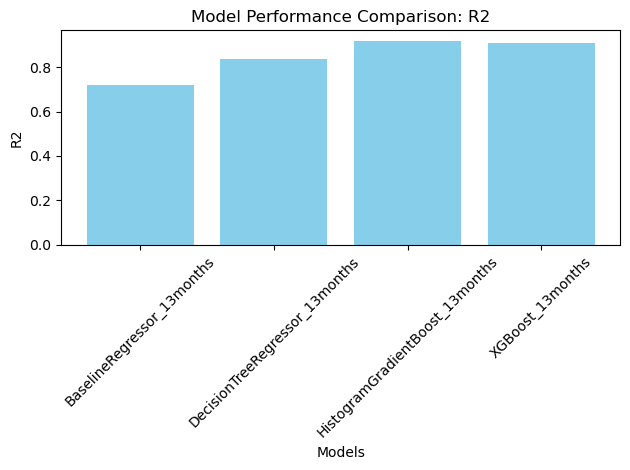

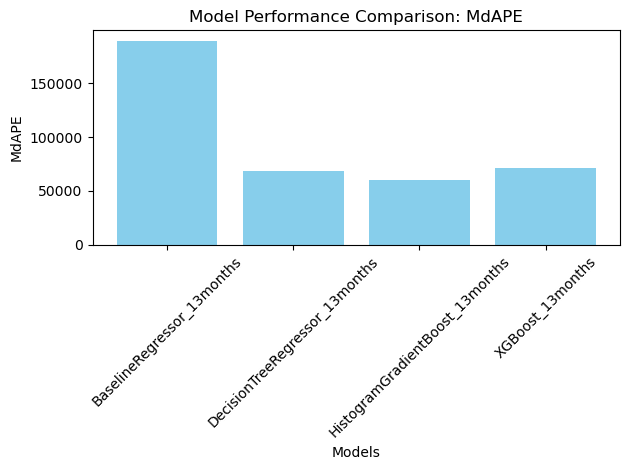

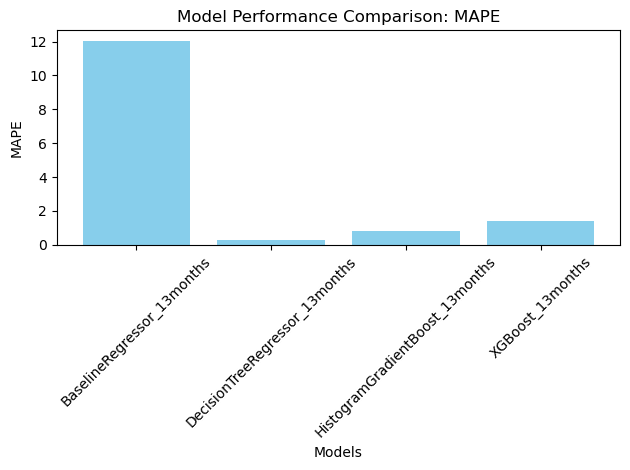

In [ ]:
# Efficacy of models. Print out bar charts showing each model's performance for each metric 
# One per test metric

test_metrics = ['R2', 'MdAPE', 'MAPE']

for metric in test_metrics:
    plt.bar(evaluations['Model'], evaluations[metric], color='skyblue')
    plt.title(f'Model Performance Comparison: {metric}')
    plt.xlabel('Models')
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

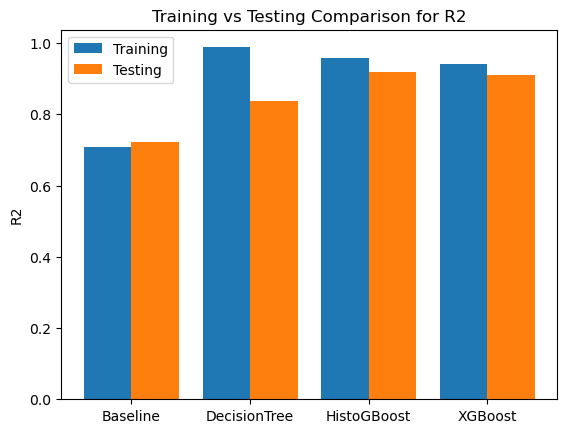

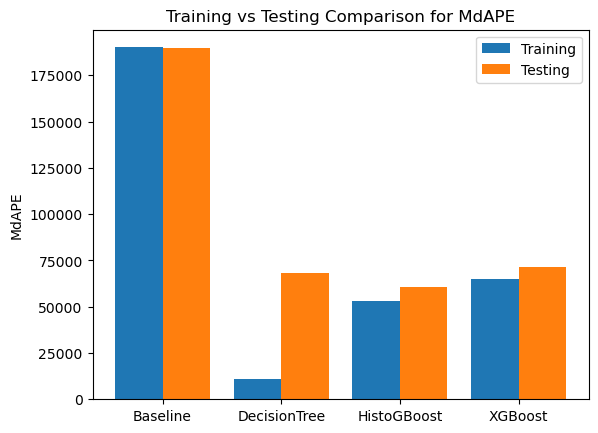

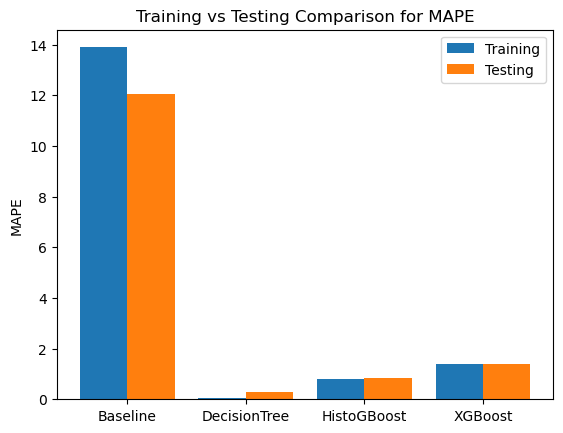

In [ ]:
# Graphs comparing their training metrics to test metrics
# https://www.geeksforgeeks.org/python/plotting-multiple-bar-charts-using-matplotlib-in-python/

cats = ['Baseline', 'DecisionTree', 'RandomForest', 'HistoGBoost', 'XGBoost'] # categories
# unblock l8r cats = ['Baseline', 'DecisionTree', 'RandomForestRegressor', 'HistogramGradientBoost', 'XGBoost'] # categories

training_metrics = ['Training_R2', 'Training_MdAPE', 'Training_MAPE']
test_metrics = ['R2', 'MdAPE', 'MAPE']
#print(evaluations[training_metrics])

for metric in test_metrics:
    training_vals, testing_vals = evaluations[f'Training_{metric}'], evaluations[metric]

    # Bar width and x locations
    w, x = 0.4, np.arange(len(cats))

    fig, ax = plt.subplots()
    ax.bar(x - w/2, training_vals, width=w, label='Training')
    ax.bar(x + w/2, testing_vals, width=w, label='Testing')

    ax.set_xticks(x)
    ax.set_xticklabels(cats)
    ax.set_ylabel(metric)
    ax.set_title(f'Training vs Testing Comparison for {metric}')
    ax.legend()

    plt.show()

# Best model:
- Histogram Gradient Boost: Best time and metrics
- Summarize insights (eg. which price bands performed better)

In [72]:
# histogram model building part 2
def histboost_for_pricebands(training_vars, training_target, price_band):
    params = {
        "max_iter": [100, 300, 500, 600, 1000],
        "max_leaf_nodes": [5, 10, 20, 50, 75, 100],
        "learning_rate": loguniform(0.01, 1),
    }
    
    # Create a GridSearch CV
    model_rand_searchcv = RandomizedSearchCV(HistGradientBoostingRegressor(), params, cv=5, 
                                                scoring={'R2': 'r2', 'MdAPE': 'neg_median_absolute_error', 'MAPE': 'neg_mean_absolute_percentage_error'}, 
                                                refit='R2', n_jobs=-1)
    # fit to data
    model_rand_searchcv.fit(training_vars, training_target)
    
    # create cv
    cv_results = pd.DataFrame(model_rand_searchcv.cv_results_)
    cv_results["R2"] = -cv_results["mean_test_R2"]
    cv_results["MdAPE"] = -cv_results["mean_test_MdAPE"]
    cv_results["MAPE"] = cv_results["mean_test_MAPE"]
    
    print(f"Histogram Gradient Boosted Performance for prices within the {price_band} Percentile:")
    print(cv_results)
    
    # return the best model
    return model_rand_searchcv.best_estimator_

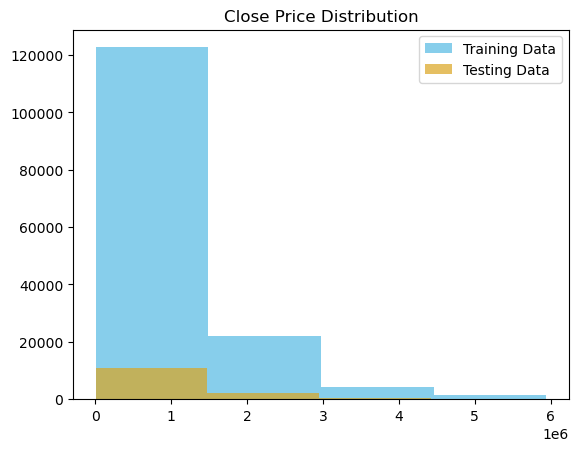

Histogram Gradient Boosted Performance for prices within the 0-25% Percentile:
   mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0       0.556586      0.050558         0.040485        0.009069   
1       0.994450      0.179244         0.079153        0.020114   
2       0.720662      0.107223         0.050088        0.008698   
3       3.786625      0.841693         0.363890        0.094111   
4       1.920864      0.046630         0.117299        0.007140   
5       1.782599      0.371497         0.151199        0.055717   
6       4.334569      0.788870         0.210546        0.054889   
7       1.585565      0.037317         0.142568        0.003340   
8       1.025435      0.095134         0.111375        0.035017   
9       0.641495      0.071283         0.045923        0.003155   

   param_learning_rate  param_max_iter  param_max_leaf_nodes  \
0             0.595510             100                    50   
1             0.233657             500                 

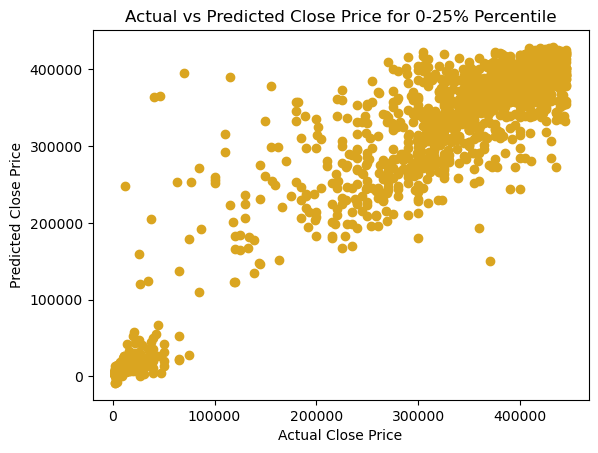

C:\Users\donutii\AppData\Local\Temp\ipykernel_7688\2645750530.py:69: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  performance_per_band = pd.concat([performance_per_band, new_row], ignore_index=True)


Histogram Gradient Boosted Performance for prices within the 26-50% Percentile:
   mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0       3.900199      1.433457         0.306276        0.162393   
1       1.077601      0.190397         0.087529        0.020564   
2       1.656329      0.598173         0.118736        0.061492   
3       1.032558      0.243758         0.067463        0.016985   
4       0.534632      0.056246         0.043778        0.008044   
5       2.159028      0.315452         0.149844        0.046658   
6       1.894120      0.024164         0.174182        0.005304   
7       0.820917      0.173110         0.060484        0.019508   
8       5.340234      0.099847         0.302507        0.007364   
9       1.066515      0.222076         0.070382        0.005670   

   param_learning_rate  param_max_iter  param_max_leaf_nodes  \
0             0.178983             500                    75   
1             0.508360             300                

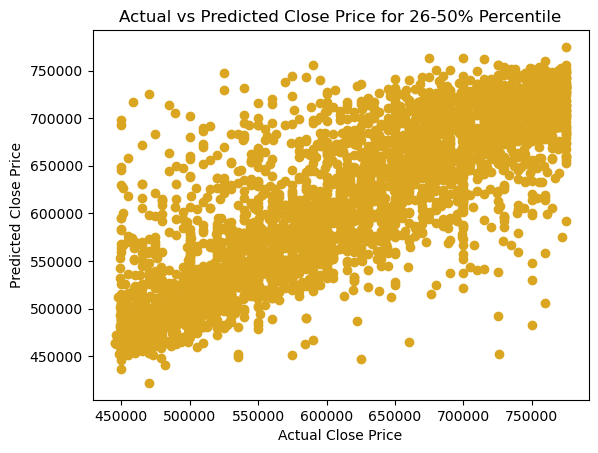

Histogram Gradient Boosted Performance for prices within the 51-90% Percentile:
   mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0       1.631102      0.159148         0.149317        0.019277   
1       6.249775      0.513307         0.600387        0.032744   
2      15.082244      5.006549         1.421033        0.681032   
3       6.895385      0.208000         0.777884        0.041990   
4      35.850120      0.739470         2.427001        0.101338   
5       2.329288      0.141973         0.205339        0.018251   
6      23.535919      2.131120         1.544906        0.124231   
7       9.846676      1.395680         0.747960        0.123596   
8       6.045361      0.851239         0.608209        0.124690   
9      13.462624      0.187875         0.894869        0.035053   

   param_learning_rate  param_max_iter  param_max_leaf_nodes  \
0             0.677603            1000                    10   
1             0.125693             500                

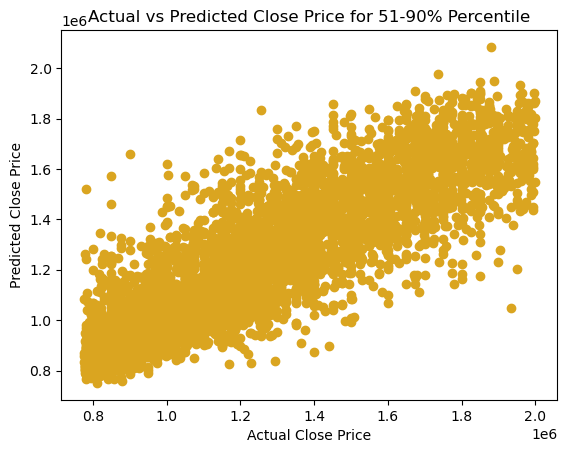

Histogram Gradient Boosted Performance for prices within the 91-100% Percentile:
   mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0       4.209879      1.248847         0.316958        0.098934   
1       2.490567      0.118651         0.193679        0.038937   
2       0.327943      0.021183         0.023142        0.002284   
3       0.450224      0.149045         0.025943        0.007401   
4       0.342947      0.062609         0.028078        0.004973   
5      11.838173      1.797690         0.437107        0.086255   
6       0.471392      0.059104         0.027579        0.002972   
7       1.998914      0.202668         0.116261        0.016886   
8       1.498212      0.071311         0.110635        0.008579   
9       0.615522      0.108796         0.043974        0.006451   

   param_learning_rate  param_max_iter  param_max_leaf_nodes  \
0             0.041026            1000                    20   
1             0.027191             500               

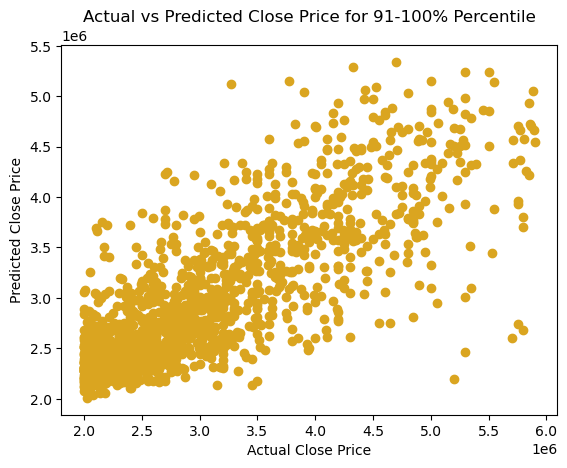

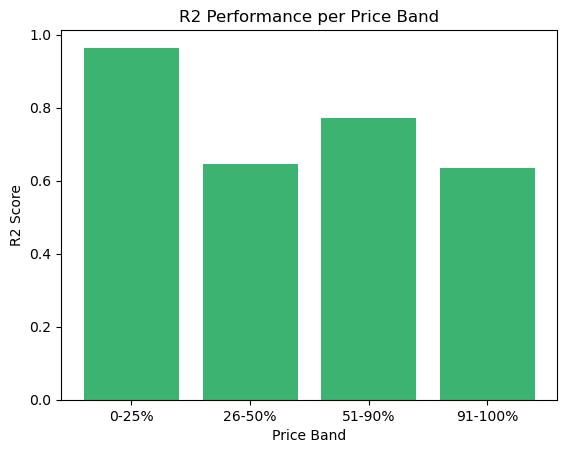

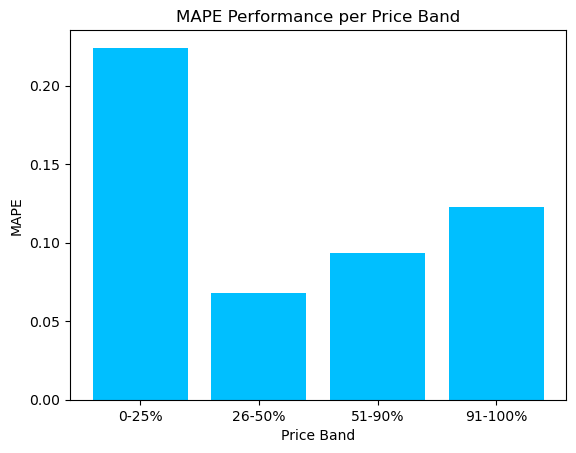

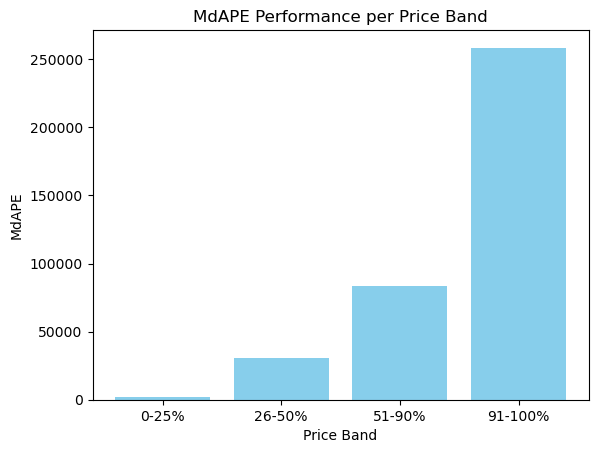

  Price_Band        R2          MdAPE      MAPE
0      0-25%  0.964399    1914.560028  0.224078
1     26-50%  0.646428   30539.915269  0.067649
2     51-90%  0.771453   83268.684676  0.093267
3    91-100%  0.635213  258407.136833  0.122402


In [ ]:
# divide model into price bands

training_data = choose_test_months(13)

# Price bands
percentiles = [0, 25, 50, 90, 100]
labels=['0-25%', '26-50%', '51-90%', '91-100%']
cuts = np.percentile(training_data['ClosePrice'], percentiles)

# Use the boundaries to create 4 bands
training_data['price_band'] = pd.cut(
    training_data['ClosePrice'],
    bins=cuts,
    labels=labels,
    include_lowest=True
)
# (Do the same to the testing set as well)
testing_set['price_band'] = pd.cut(
    testing_set['ClosePrice'],
    bins=cuts,
    labels=labels,
    include_lowest=True,
    )

# Display price band dist
plt.hist(training_data['ClosePrice'], bins=len(labels), color='skyblue', label='Training Set')
plt.hist(testing_set['ClosePrice'], bins=len(labels), color='goldenrod', alpha=0.7, label='Testing Set')
plt.title('Close Price Distribution')
plt.legend(['Training Data', 'Testing Data'])
plt.show()

# Split into separate DataFrames by price band
band_dfs = {
    band: df for band, df in training_data.groupby('price_band', observed=True)
}

# Train best model per band
performance_per_band = pd.DataFrame(columns=['Price_Band', 'R2', 'MdAPE', 'MAPE'])

for band, df in band_dfs.items():
    X = df.drop(columns=['ClosePrice', 'price_band'])
    y = df['ClosePrice']
    histboost_model = histboost_for_pricebands(X, y, band)
    test_band_df = testing_set[testing_set['price_band'] == band]
    if test_band_df.shape[0] == 0:
        new_row = pd.DataFrame([{
            'Price_Band': band,
            'R2': np.nan,
            'MdAPE': np.nan,
            'MAPE': np.nan
        }])
    else:
        X_test_band = test_band_df.drop(columns=['ClosePrice', 'price_band'])
        y_test_band = test_band_df['ClosePrice']
        new_row = pd.DataFrame([{
            'Price_Band': band,
            'R2': histboost_model.score(X_test_band, y_test_band),
            'MdAPE': median_absolute_error(y_test_band, histboost_model.predict(X_test_band)),
            'MAPE': mean_absolute_percentage_error(y_test_band, histboost_model.predict(X_test_band))
        }])
        
        plt.scatter(y_test_band, histboost_model.predict(X_test_band), color='goldenrod')
        plt.xlabel('Actual Close Price')
        plt.ylabel('Predicted Close Price')
        plt.title(f'Actual vs Histogram Gradient Boosted Predicted Close Price for {band} Percentile')
        plt.show()
        
        
    performance_per_band = pd.concat([performance_per_band, new_row], ignore_index=True)     

plt.bar(performance_per_band['Price_Band'], performance_per_band['R2'], color='mediumseagreen')
plt.title('R2 Performance per Price Band')
plt.xlabel('Price Band')
plt.ylabel('R2 Score')
plt.show()

plt.bar(performance_per_band['Price_Band'], performance_per_band['MAPE'], color='deepskyblue')
plt.title('MAPE Performance per Price Band')
plt.xlabel('Price Band')
plt.ylabel('MAPE')
plt.show()

plt.bar(performance_per_band['Price_Band'], performance_per_band['MdAPE'], color='skyblue')
plt.title('MdAPE Performance per Price Band')
plt.xlabel('Price Band')
plt.ylabel('MdAPE')
plt.show()

print(performance_per_band)



In [91]:
# Consolidate and export evaluations here

performance_per_band.to_csv('histgrad_perfermance_per_priceband.csv', index = False)